# 1. Importación de Bibliotecas

In [ ]:
import numpy as np
import torch
from IPython.display import display, Markdown, Latex
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 2. Verificación si CUDA está disponible y nombre del GPU

In [ ]:
print(f"¿CUDA disponible?: {torch.cuda.is_available()}")

# Si es true, imprime el nombre de tu GPU
if torch.cuda.is_available():
    print(f"GPU detectada: {torch.cuda.get_device_name(0)}")

¿CUDA disponible?: True
GPU detectada: Tesla T4


# 3. Manejo de Imagenes entre Numpy y PyTorch
 A. Creamos una imagen simulada con NumPy (Formato: Height, Width, Channels)
 Una imagen de 64x64 píxeles con 3 canales (RGB)

In [ ]:
imagen_numpy = np.random.rand(64, 64, 3).astype(np.float32)

# B. Convertimos de NumPy a Tensor de PyTorch
# IMPORTANTE: PyTorch espera el formato (Channels, Height, Width)
# Usamos transpose para reordenar los ejes
imagen_tensor = torch.from_numpy(imagen_numpy.transpose(2, 0, 1))

print(f"Forma original (NumPy): {imagen_numpy.shape}")
print(f"Forma en tensor (PyTorch): {imagen_tensor.shape}")

# C. Mover a la GPU (CUDA)
if torch.cuda.is_available():
    imagen_tensor = imagen_tensor.to('cuda')
    print("El tensor ha sido enviado a la GPU.")
else:
    print("CUDA no disponible, el tensor permanece en la CPU.")

# D. Regresar a NumPy (por ejemplo, para visualizarla con Matplotlib)
# Si está en la GPU, primero debemos regresarla a la CPU y quitarle el gradiente
imagen_final = imagen_tensor.cpu().detach().numpy().transpose(1, 2, 0)

print(f"Forma final (NumPy): {imagen_final.shape}")

Forma original (NumPy): (64, 64, 3)
Forma en tensor (PyTorch): torch.Size([3, 64, 64])
El tensor ha sido enviado a la GPU.
Forma final (NumPy): (64, 64, 3)


# 4. Conexión con Convoluciones

In [ ]:
conexiones_con_convoluciones="""Esta base de **álgebra lineal** es fundamental porque:

- **Cada convolución es una suma de productos punto locales.**
- **Los filtros son pequeños vectores o matrices que se multiplican contra regiones locales.**
- **La optimización (backpropagation) ajusta estos pesos usando derivadas, que también se basan en producto punto.**
"""
display(Markdown(conexiones_con_convoluciones))

Esta base de **álgebra lineal** es fundamental porque:

- **Cada convolución es una suma de productos punto locales.**
- **Los filtros son pequeños vectores o matrices que se multiplican contra regiones locales.**
- **La optimización (backpropagation) ajusta estos pesos usando derivadas, que también se basan en producto punto.**


# 5. Convolución como Operación Lineal

In [ ]:
convolucion_como_operacion_lineal=r"""

Una **convolución** es una operación lineal local. Aplicamos un **filtro (kernel)** sobre regiones de entrada, calculando productos punto locales:

$$
\text{Output}_{(i,j)} = \sum_{u,v} \text{Input}_{(i+u,\,j+v)} \cdot \text{Kernel}_{(u,v)}
$$
"""
display(Markdown(convolucion_como_operacion_lineal))



Una **convolución** es una operación lineal local. Aplicamos un **filtro (kernel)** sobre regiones de entrada, calculando productos punto locales:

$$
\text{Output}_{(i,j)} = \sum_{u,v} \text{Input}_{(i+u,\,j+v)} \cdot \text{Kernel}_{(u,v)}
$$


# 6. Ejemplo de Convolución
 Representación 2d de una P

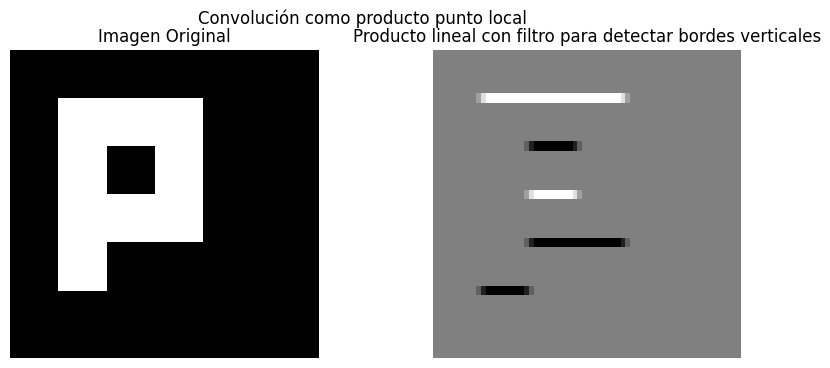

In [ ]:
P_img = np.zeros((64, 64))
P_img[10:50, 10:20] = 1
P_img[10:20, 10:40] = 1
P_img[30:40, 10:40] = 1
P_img[20:30, 30:40] = 1
P_img[20:30, 20:30] = 0
img_P = torch.tensor(P_img, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

# Filtro Sobel vertical (Detección de Bordes Verticales)
kernel = torch.tensor([[-1., -2., -1.],
                       [ 0.,  0.,  0.],
                       [ 1.,  2.,  1.]]).unsqueeze(0).unsqueeze(0)

output_P = F.conv2d(img_P, kernel, padding='same')

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(P_img.squeeze(), cmap='gray')
plt.title("Imagen Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(output_P.squeeze().detach(), cmap='gray')
plt.title("Producto lineal con filtro para detectar bordes verticales")
plt.axis('off')
plt.suptitle("Convolución como producto punto local")
plt.show()

# 7.Convolución más Detallada

In [ ]:
np.set_printoptions(threshold=np.inf, linewidth=200)
print(P_img.astype(int))

# Coordenadas del centro (recordar a contar desde 0)
i, j = 10, 10

window = img_P.squeeze().cpu().numpy()[i-1:i+2, j-1:j+2]
print(f"Ventana 3x3 centrada en ({i},{j}):")
print(window)

[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

# 8. 🧠 Ejemplo de operación de convolución

In [ ]:
texto_convolucion = """Tomemos la siguiente región 3×3 de la imagen:

**Input**:

$$
\\begin{bmatrix}
0 & 0 & 0 \\\\
0 & 1 & 1 \\\\
0 & 1 & 1
\\end{bmatrix}
$$

**Kernel (Sobel vertical)**:

$$
\\begin{bmatrix}
-1 & -2 & -1 \\\\
 0 &  0 &  0 \\\\
 1 &  2 &  1
\\end{bmatrix}
$$

**Cálculo del producto punto local**:

$$
(-1)\\cdot 0 \\;+\\; (-2)\\cdot 0 \\;+\; (-1)\\cdot 0\\;+\\; 0\\cdot 0\\;+\\; 0\\cdot 1\\;+\\; 0\\cdot 1\\;+\\; 1\\cdot 0\\;+\\; 2\\cdot 1\\;+\\; 1\\cdot 1
$$

$$
= 0 + 0 + 0 + 0 + 0 + 0 + 0 + 2 + 1 = 3
$$

**Resultado final**: `3`
"""

display(Markdown(texto_convolucion))

<>:26: SyntaxWarning: invalid escape sequence '\;'
<>:26: SyntaxWarning: invalid escape sequence '\;'
/tmp/ipykernel_2085/2674567709.py:26: SyntaxWarning: invalid escape sequence '\;'
  (-1)\\cdot 0 \\;+\\; (-2)\\cdot 0 \\;+\; (-1)\\cdot 0\\;+\\; 0\\cdot 0\\;+\\; 0\\cdot 1\\;+\\; 0\\cdot 1\\;+\\; 1\\cdot 0\\;+\\; 2\\cdot 1\\;+\\; 1\\cdot 1


Tomemos la siguiente región 3×3 de la imagen:

**Input**:

$$
\begin{bmatrix}
0 & 0 & 0 \\
0 & 1 & 1 \\
0 & 1 & 1
\end{bmatrix}
$$

**Kernel (Sobel vertical)**:

$$
\begin{bmatrix}
-1 & -2 & -1 \\
 0 &  0 &  0 \\
 1 &  2 &  1
\end{bmatrix}
$$

**Cálculo del producto punto local**:

$$
(-1)\cdot 0 \;+\; (-2)\cdot 0 \;+\; (-1)\cdot 0\;+\; 0\cdot 0\;+\; 0\cdot 1\;+\; 0\cdot 1\;+\; 1\cdot 0\;+\; 2\cdot 1\;+\; 1\cdot 1
$$

$$
= 0 + 0 + 0 + 0 + 0 + 0 + 0 + 2 + 1 = 3
$$

**Resultado final**: `3`


# 9. Operaciones
 1) Convertir 'output' a NumPy 2D (sacando batch y channel)

In [ ]:
out_np = output_P.squeeze().detach().cpu().numpy()

# 2) Configurar numpy para imprimir todo el array sin cortes y en una sola línea
np.set_printoptions(threshold=np.inf, linewidth=200)

# 3) Imprimir como enteros, sin comas, de forma prolija
print(out_np.astype(int))

# 3) Verificar el valor en (i, j)
i, j = 10, 10
print(f"\nValor en la posición ({i},{j}):", out_np[i, j])

[[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0

# 10. Dimensiones y Transformaciones

In [ ]:
Dimensiones_y_transformaciones="""
### 2.5) Dimensiones y transformaciones

En redes convolucionales usamos tensores con forma:

```python
(batch_size, channels, height, width)  # ➜ Ejemplo: (1, 3, 64, 64)
```

- `batch_size`: cantidad de imágenes procesadas juntas.
- `channels`: 1 (grayscale), 3 (RGB), o más.
- `height`, `width`: tamaño espacial de la imagen.
"""
display(Markdown(Dimensiones_y_transformaciones))


### 2.5) Dimensiones y transformaciones

En redes convolucionales usamos tensores con forma:

```python
(batch_size, channels, height, width)  # ➜ Ejemplo: (1, 3, 64, 64)
```

- `batch_size`: cantidad de imágenes procesadas juntas.
- `channels`: 1 (grayscale), 3 (RGB), o más.
- `height`, `width`: tamaño espacial de la imagen.


# 11.💡 Tips

In [ ]:
tips="""- **Entender tensores y sus dimensiones** es clave para evitar errores al construir arquitecturas.
- Muchas veces, errores de "shape" se deben a mal uso del batch o canales. Siempre inspeccioná con `tensor.shape`.
- Pensar las convoluciones como productos punto ayuda a entender qué hacen los filtros y cómo se ajustan.
"""
display(Markdown(tips))

- **Entender tensores y sus dimensiones** es clave para evitar errores al construir arquitecturas.
- Muchas veces, errores de "shape" se deben a mal uso del batch o canales. Siempre inspeccioná con `tensor.shape`.
- Pensar las convoluciones como productos punto ayuda a entender qué hacen los filtros y cómo se ajustan.


## 💡